## Distance Loss Analysis

In [1]:
# setup

import sys
import torch
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

sys.path.append(str(Path.cwd().parent / "src"))

from data import (build_vocab, encode, make_chunks, CharDataset,
                  find_anchor_positions, ANCHOR_NAMES)
from rnn import VanillaRNN
from lstm import LSTMModel
from torch.utils.data import DataLoader

device = torch.device("cpu")

PROCESSED_DATA_DIR = Path.cwd().parent / "data" / "processed"
CHECKPOINT_DIR     = Path.cwd().parent / "checkpoints"
FIGURES_DIR        = Path.cwd().parent / "results" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

with open(PROCESSED_DATA_DIR / "corpus_clean.txt", "r", encoding="utf-8") as f:
    text = f.read()

train_text = text[:738058]
test_text  = text[897611:]

char2idx, idx2char = build_vocab(train_text, min_count=10)
vocab_size = len(idx2char)

print(f"Vocab size:   {vocab_size}")
print(f"Test chars:   {len(test_text):,}")

Vocab size:   71
Test chars:   233,677


In [2]:
# loading trained models

rnn_model = VanillaRNN(vocab_size=vocab_size, embed_dim=64, hidden_size=256)
rnn_checkpoint = torch.load(CHECKPOINT_DIR / "rnn_best.pt", map_location=device)
rnn_model.load_state_dict(rnn_checkpoint["model_state_dict"])
rnn_model.to(device)
rnn_model.eval()

lstm_model = LSTMModel(vocab_size=vocab_size, embed_dim=64, hidden_size=256)
lstm_checkpoint = torch.load(CHECKPOINT_DIR / "lstm_best.pt", map_location=device)
lstm_model.load_state_dict(lstm_checkpoint["model_state_dict"])
lstm_model.to(device)
lstm_model.eval()

print(f"RNN  loaded — val loss: {rnn_checkpoint['val_loss']:.4f}")
print(f"LSTM loaded — val loss: {lstm_checkpoint['val_loss']:.4f}")

RNN  loaded — val loss: 1.4449
LSTM loaded — val loss: 1.4327


In [3]:
# computing per-character loss

def get_per_char_losses(model, encoded_text, model_type="rnn",
                        seq_len=100, batch_size=64):

    criterion = torch.nn.CrossEntropyLoss(reduction="none")
    all_losses = []

    chunks = make_chunks(encoded_text, seq_len=seq_len)

    dataset    = CharDataset(chunks)
    loader     = DataLoader(dataset, batch_size=batch_size,
                            shuffle=False, drop_last=True)

    h = model.init_hidden(batch_size, device)
    if model_type == "lstm":
        h, c = h

    with torch.no_grad():
        for input_seq, target_seq in loader:
            input_seq  = input_seq.to(device)
            target_seq = target_seq.to(device)

            if model_type == "rnn":
                h = h.detach()
                logits, h, _ = model(input_seq, h)
            else:
                h = h.detach()
                c = c.detach()
                logits, h, c, _ = model(input_seq, h, c)

            loss = criterion(
                logits.view(-1, logits.size(-1)),
                target_seq.view(-1)
            )
            all_losses.extend(loss.cpu().numpy())

    return np.array(all_losses)


test_encoded = encode(test_text, char2idx)

print("Computing per-character losses for RNN...")
rnn_losses = get_per_char_losses(rnn_model, test_encoded, model_type="rnn")

print("Computing per-character losses for LSTM...")
lstm_losses = get_per_char_losses(lstm_model, test_encoded, model_type="lstm")

print(f"\nRNN  — total positions: {len(rnn_losses):,}, "
      f"mean loss: {rnn_losses.mean():.4f}")
print(f"LSTM — total positions: {len(lstm_losses):,}, "
      f"mean loss: {lstm_losses.mean():.4f}")

Computing per-character losses for RNN...
Computing per-character losses for LSTM...

RNN  — total positions: 230,400, mean loss: 1.4363
LSTM — total positions: 230,400, mean loss: 1.4216


In [4]:
# computing anchor distances

anchor_positions = find_anchor_positions(test_text, ANCHOR_NAMES)

print("Anchor occurrences in test set:")
for name, positions in anchor_positions.items():
    print(f"  {name}: {len(positions)} occurrences")

def compute_distances(text_len, positions):

    distances = np.full(text_len, -1, dtype=np.int32)

    for i, pos in enumerate(positions):
        prev_pos = positions[i - 1] if i > 0 else None
        if prev_pos is None:
            continue
        for p in range(prev_pos, pos):
            distances[p] = p - prev_pos

    return distances

all_distances = np.full(len(test_text), -1, dtype=np.int32)

for name, positions in anchor_positions.items():
    name_distances = compute_distances(len(test_text), positions)

    valid = (name_distances >= 0)
    all_distances[valid] = np.where(
        all_distances[valid] < 0,
        name_distances[valid],
        np.minimum(all_distances[valid], name_distances[valid])
    )

valid_positions = (all_distances >= 0).sum()
print(f"\nPositions with valid distance (after first anchor occurrence): "
      f"{valid_positions:,} / {len(test_text):,}")

Anchor occurrences in test set:
  Raskolnikov: 177 occurrences
  Sonia: 73 occurrences
  Razumihin: 48 occurrences
  Dounia: 97 occurrences
  Katerina: 9 occurrences
  Porfiry: 53 occurrences

Positions with valid distance (after first anchor occurrence): 231,636 / 233,677


In [5]:
# calculating bucket losses by distance
BUCKETS = [
    (0,    50,   "0–50"),
    (50,   100,  "50–100"),
    (100,  200,  "100–200"),
    (200,  500,  "200–500"),
    (500,  1000, "500–1000"),
    (1000, None, "1000+"),
]

n_loss_positions = len(rnn_losses)

rnn_bucket_means  = []
lstm_bucket_means = []
bucket_labels     = []
bucket_counts     = []

for low, high, label in BUCKETS:

    if high is None:
        mask = (all_distances[:n_loss_positions] >= low) & \
               (all_distances[:n_loss_positions] >= 0)
    else:
        mask = (all_distances[:n_loss_positions] >= low) & \
               (all_distances[:n_loss_positions] < high) & \
               (all_distances[:n_loss_positions] >= 0)

    count = mask.sum()
    if count == 0:
        print(f"Bucket {label}: no samples — skipping")
        continue

    rnn_bucket_means.append(rnn_losses[mask].mean())
    lstm_bucket_means.append(lstm_losses[mask].mean())
    bucket_labels.append(label)
    bucket_counts.append(count)

    print(f"Bucket {label:12s}: {count:6,} positions | "
          f"RNN loss: {rnn_losses[mask].mean():.4f} | "
          f"LSTM loss: {lstm_losses[mask].mean():.4f}")

Bucket 0–50        : 21,489 positions | RNN loss: 1.2076 | LSTM loss: 1.1950
Bucket 50–100      : 18,190 positions | RNN loss: 1.4116 | LSTM loss: 1.4029
Bucket 100–200     : 28,294 positions | RNN loss: 1.4245 | LSTM loss: 1.4106
Bucket 200–500     : 49,340 positions | RNN loss: 1.4316 | LSTM loss: 1.4163
Bucket 500–1000    : 35,405 positions | RNN loss: 1.4752 | LSTM loss: 1.4614
Bucket 1000+       : 77,033 positions | RNN loss: 1.4953 | LSTM loss: 1.4782


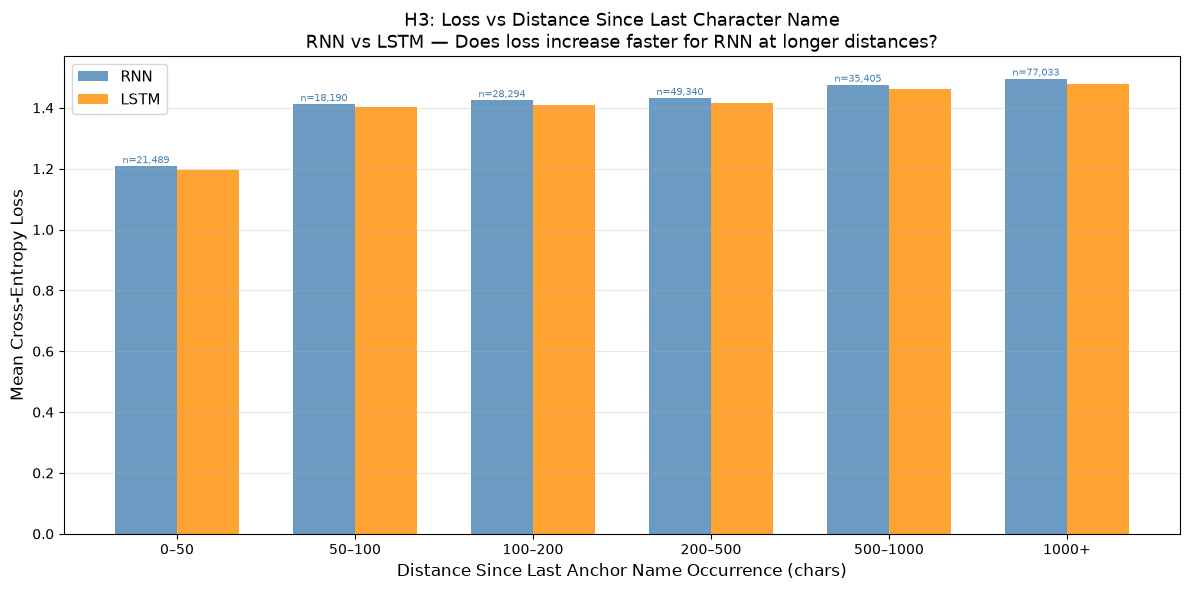

Saved to results/figures/distance_loss_analysis.png


In [6]:
# plotting the results

x = np.arange(len(bucket_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars_rnn  = ax.bar(x - width/2, rnn_bucket_means,  width,
                   label="RNN",  color="steelblue",  alpha=0.8)
bars_lstm = ax.bar(x + width/2, lstm_bucket_means, width,
                   label="LSTM", color="darkorange", alpha=0.8)

for i, (bar, count) in enumerate(zip(bars_rnn, bucket_counts)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"n={count:,}", ha="center", va="bottom", fontsize=7,
            color="steelblue")

ax.set_xlabel("Distance Since Last Anchor Name Occurrence (chars)", fontsize=12)
ax.set_ylabel("Mean Cross-Entropy Loss", fontsize=12)
ax.set_title("H3: Loss vs Distance Since Last Character Name\n"
             "RNN vs LSTM — Does loss increase faster for RNN at longer distances?",
             fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(bucket_labels, fontsize=10)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "distance_loss_analysis.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("Saved to results/figures/distance_loss_analysis.png")